In [ ]:
                                                                                                                                                                                                                           import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# index 0 dành cho padding — quy ước phổ biến.
vocab = {'': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token  bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


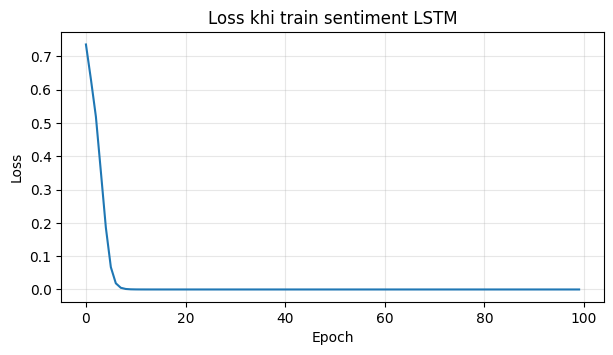

In [ ]:
X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()


In [ ]:
# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


In [ ]:
def make_long_dependency_data(n_samples=500, seq_len=30, n_noise_tokens=8):
    # Sinh dữ liệu mà nhãn phụ thuộc vào ký tự đầu tiên, các bước giữa là nhiễu.
    # Token 0 hoặc 1: signal. Token 2..n_noise_tokens+1: noise.
    X, y = [], []
    for _ in range(n_samples):
        signal = np.random.randint(0, 2)            # 0 hoặc 1
        noise = np.random.randint(2, 2 + n_noise_tokens, size=seq_len - 1)
        seq = np.concatenate([[signal], noise])
        X.append(seq); y.append(signal)
    return torch.tensor(np.array(X), dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xs_train, ys_train = make_long_dependency_data(800)
Xs_test,  ys_test  = make_long_dependency_data(200)
print('train shape:', Xs_train.shape, ' test shape:', Xs_test.shape)
print('Ví dụ một chuỗi:', Xs_train[0].tolist(), '   nhãn:', ys_train[0].item())

train shape: torch.Size([800, 30])  test shape: torch.Size([200, 30])
Ví dụ một chuỗi: [0, 5, 6, 8, 4, 9, 6, 6, 8, 3, 4, 8, 4, 4, 9, 6, 5, 9, 9, 4, 7, 6, 3, 9, 5, 7, 7, 3, 9, 5]    nhãn: 0


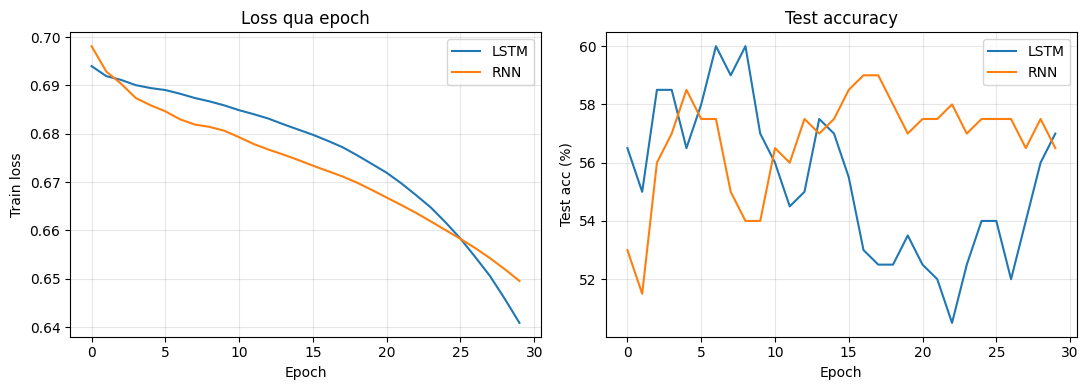

LSTM final test acc: 57.00%
RNN  final test acc: 56.50%

LSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).


In [ ]:
class TokenModel(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=8, hidden_dim=16, cell='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if cell == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 2)
        self.cell = cell

    def forward(self, x):
        e = self.embedding(x)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(e)
        else:
            _, h_n = self.rnn(e)
        return self.fc(h_n.squeeze(0))

def train_compare(cell, epochs=30, lr=0.01):
    torch.manual_seed(42)
    m = TokenModel(cell=cell).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xt, yt = Xs_train.to(device), ys_train.to(device)
    Xv, yv = Xs_test.to(device),  ys_test.to(device)
    losses, accs = [], []
    for ep in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        loss.backward()
        opt.step()
        m.eval()
        with torch.no_grad():
            acc = (m(Xv).argmax(1) == yv).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

losses_lstm, accs_lstm = train_compare('lstm')
losses_rnn,  accs_rnn  = train_compare('rnn')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_lstm, label='LSTM'); axes[0].plot(losses_rnn, label='RNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua epoch')
axes[1].plot([a*100 for a in accs_lstm], label='LSTM')
axes[1].plot([a*100 for a in accs_rnn],  label='RNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

print(f'LSTM final test acc: {accs_lstm[-1]*100:.2f}%')
print(f'RNN  final test acc: {accs_rnn[-1]*100:.2f}%')
print('\nLSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).')


## Bài 1: Dự báo chuỗi thời gian bằng LSTM

### 1. Tạo chuỗi thời gian và chuẩn hóa dữ liệu

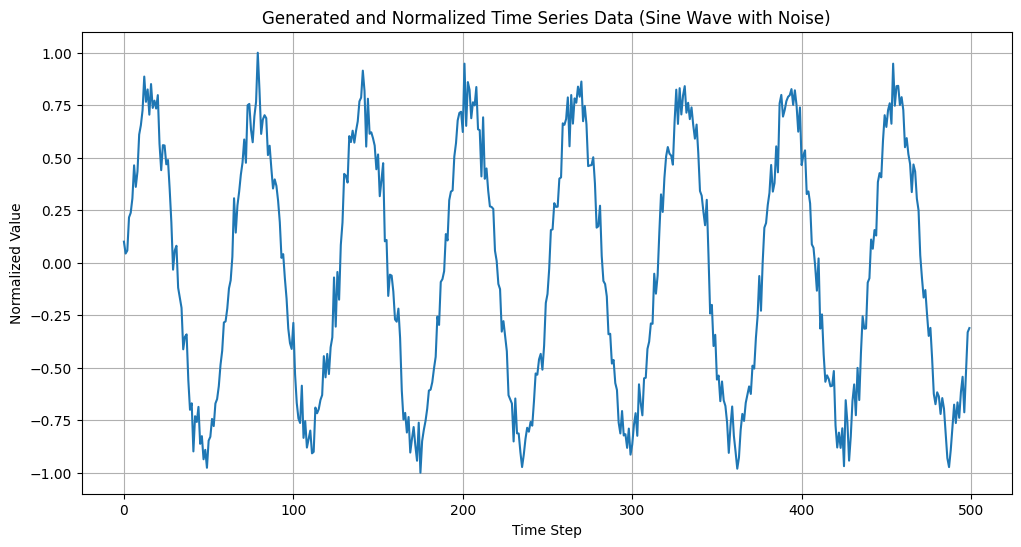

Data shape: torch.Size([500, 1])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

# Generate a sine wave with some noise
n_points = 500
time = np.arange(0, n_points)
sine_wave = np.sin(time / 10.0) * 5 + np.random.randn(n_points) * 0.5

# Normalize the data
scaler = MinMaxScaler(feature_range=(-1, 1))
data = scaler.fit_transform(sine_wave.reshape(-1, 1))
data = torch.tensor(data, dtype=torch.float32)

plt.figure(figsize=(12, 6))
plt.plot(time, data.numpy())
plt.title('Generated and Normalized Time Series Data (Sine Wave with Noise)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.show()

print(f'Data shape: {data.shape}')

### 2. Tạo cửa sổ trượt và chia tập train/val/test

In [ ]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)

seq_length = 20
X, y = create_sequences(data, seq_length)

# Split data into train, validation, and test sets (70/15/15) based on time order
total_samples = len(X)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f'Original data shape: {data.shape}')
print(f'Sequences X shape: {X.shape}, y shape: {y.shape}')
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

Original data shape: torch.Size([500, 1])
Sequences X shape: torch.Size([480, 20, 1]), y shape: torch.Size([480, 1])
X_train shape: torch.Size([336, 20, 1]), y_train shape: torch.Size([336, 1])
X_val shape: torch.Size([72, 20, 1]), y_val shape: torch.Size([72, 1])
X_test shape: torch.Size([72, 20, 1]), y_test shape: torch.Size([72, 1])


### 3. Xây dựng mô hình LSTM và RNN cơ bản

In [ ]:
import torch.nn as nn

class TimeSeriesPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, model_type='lstm'):
        super().__init__()
        self.hidden_size = hidden_size
        self.model_type = model_type

        if model_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        elif model_type == 'rnn':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        else:
            raise ValueError("model_type must be 'lstm' or 'rnn'")

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        if self.model_type == 'lstm':
            _, (h_n, c_n) = self.rnn(x)
        else: # rnn
            _, h_n = self.rnn(x)

        # h_n shape: (num_layers * num_directions, batch_size, hidden_size)
        # We take the last hidden state (h_n) from the last layer (squeeze 0 for single layer)
        out = self.fc(h_n.squeeze(0)) # out shape: (batch_size, output_size)
        return out

# Instantiate models
input_size = 1 # Our data has one feature (value)
hidden_size = 32
output_size = 1 # We predict one next value

model_lstm = TimeSeriesPredictor(input_size, hidden_size, output_size, model_type='lstm').to(device)
model_rnn = TimeSeriesPredictor(input_size, hidden_size, output_size, model_type='rnn').to(device)

print(model_lstm)
print(model_rnn)

TimeSeriesPredictor(
  (rnn): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
TimeSeriesPredictor(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### 4. Train mô hình và đánh giá

In [ ]:
import torch.optim as optim
import torch.nn as nn

def train_model(model, X_train, y_train, X_val, y_val, epochs=100, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            val_losses.append(val_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    return train_losses, val_losses

print("\n--- Training LSTM Model ---")
train_losses_lstm, val_losses_lstm = train_model(model_lstm, X_train, y_train, X_val, y_val)

print("\n--- Training RNN Model ---")
train_losses_rnn, val_losses_rnn = train_model(model_rnn, X_train, y_train, X_val, y_val)


--- Training LSTM Model ---
Epoch  10, Train Loss: 0.3150, Val Loss: 0.3564
Epoch  20, Train Loss: 0.2749, Val Loss: 0.3056
Epoch  30, Train Loss: 0.2216, Val Loss: 0.2417
Epoch  40, Train Loss: 0.1562, Val Loss: 0.1607
Epoch  50, Train Loss: 0.1145, Val Loss: 0.1089
Epoch  60, Train Loss: 0.0622, Val Loss: 0.0591
Epoch  70, Train Loss: 0.0094, Val Loss: 0.0136
Epoch  80, Train Loss: 0.0088, Val Loss: 0.0109
Epoch  90, Train Loss: 0.0102, Val Loss: 0.0115
Epoch 100, Train Loss: 0.0090, Val Loss: 0.0114

--- Training RNN Model ---
Epoch  10, Train Loss: 0.2062, Val Loss: 0.2118
Epoch  20, Train Loss: 0.0951, Val Loss: 0.0913
Epoch  30, Train Loss: 0.0572, Val Loss: 0.0496
Epoch  40, Train Loss: 0.0355, Val Loss: 0.0340
Epoch  50, Train Loss: 0.0248, Val Loss: 0.0231
Epoch  60, Train Loss: 0.0182, Val Loss: 0.0182
Epoch  70, Train Loss: 0.0139, Val Loss: 0.0145
Epoch  80, Train Loss: 0.0119, Val Loss: 0.0136
Epoch  90, Train Loss: 0.0112, Val Loss: 0.0134
Epoch 100, Train Loss: 0.0106, 

### 5. Đánh giá và so sánh

MSE on Test set for LSTM: 0.009407


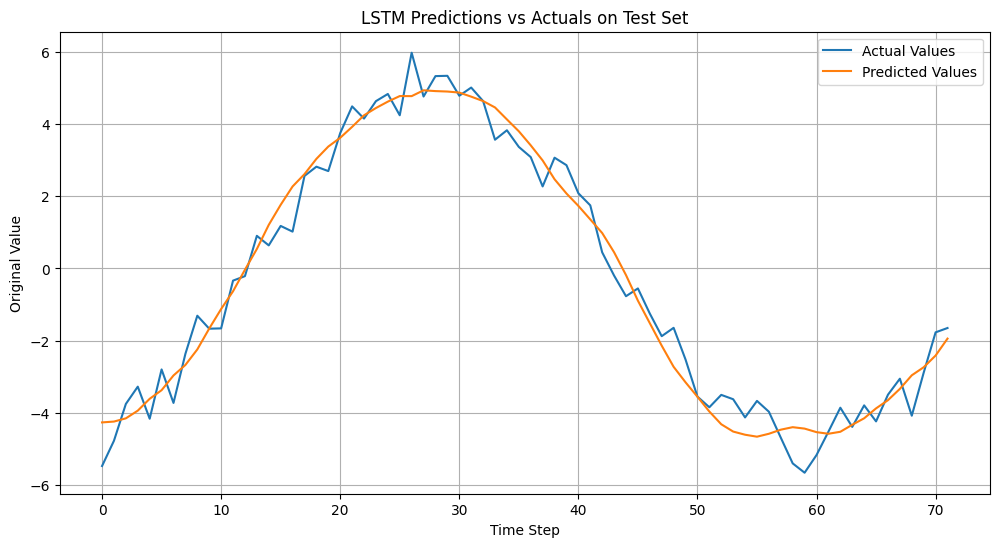

MSE on Test set for RNN: 0.011311


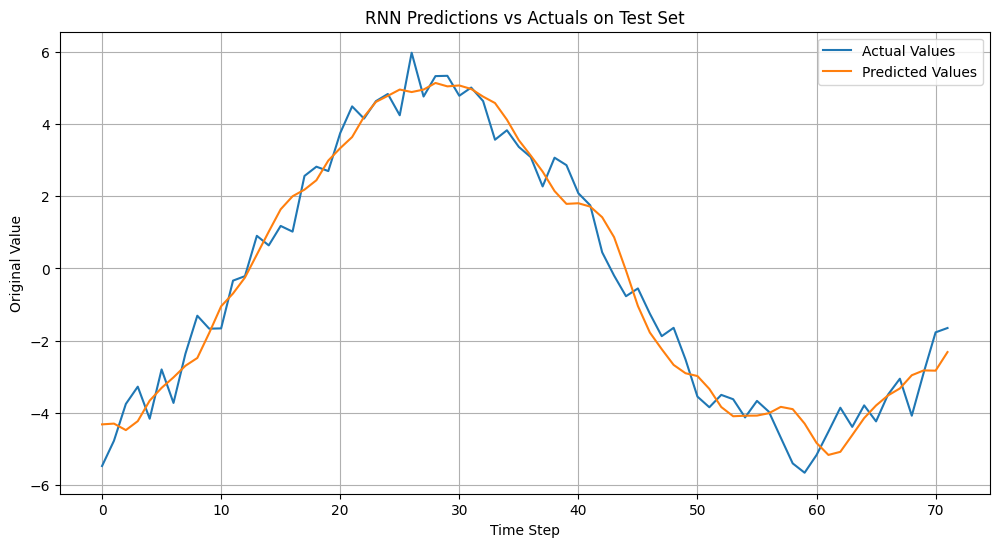

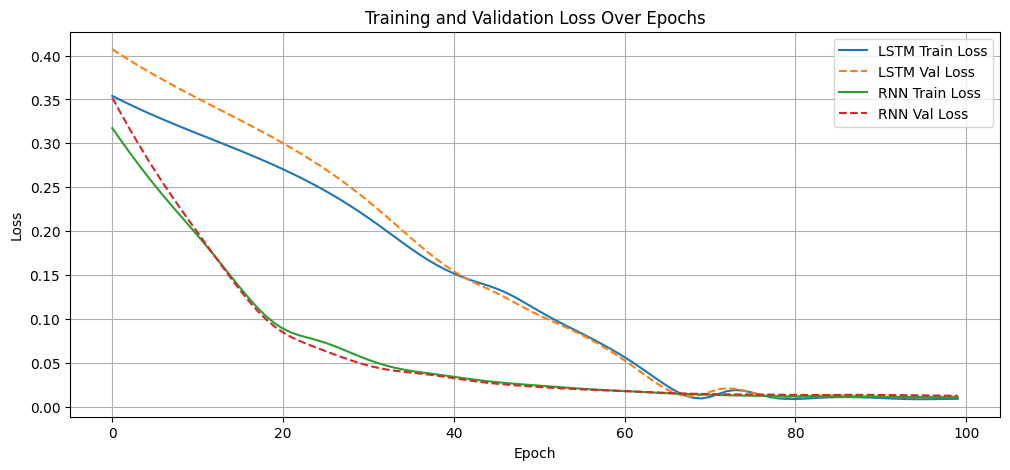


Final Comparison:
LSTM Test MSE: 0.009407
RNN Test MSE: 0.011311
LSTM performed better than RNN.


In [ ]:
from sklearn.metrics import mean_squared_error

def evaluate_model(model, X_test, y_test, model_name):
    model.eval()
    X_test, y_test = X_test.to(device), y_test.to(device)
    with torch.no_grad():
        predictions = model(X_test)

    mse = mean_squared_error(y_test.cpu().numpy(), predictions.cpu().numpy())
    print(f'MSE on Test set for {model_name}: {mse:.6f}')

    # Inverse transform to original scale for plotting
    actual_values = scaler.inverse_transform(y_test.cpu().numpy())
    predicted_values = scaler.inverse_transform(predictions.cpu().numpy())

    plt.figure(figsize=(12, 6))
    plt.plot(actual_values, label='Actual Values')
    plt.plot(predicted_values, label='Predicted Values')
    plt.title(f'{model_name} Predictions vs Actuals on Test Set')
    plt.xlabel('Time Step')
    plt.ylabel('Original Value')
    plt.legend()
    plt.grid(True)
    plt.show()
    return mse

mse_lstm = evaluate_model(model_lstm, X_test, y_test, 'LSTM')
mse_rnn = evaluate_model(model_rnn, X_test, y_test, 'RNN')


# Plotting training/validation loss
plt.figure(figsize=(12, 5))
plt.plot(train_losses_lstm, label='LSTM Train Loss')
plt.plot(val_losses_lstm, label='LSTM Val Loss', linestyle='--')
plt.plot(train_losses_rnn, label='RNN Train Loss')
plt.plot(val_losses_rnn, label='RNN Val Loss', linestyle='--')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'\nFinal Comparison:')
print(f'LSTM Test MSE: {mse_lstm:.6f}')
print(f'RNN Test MSE: {mse_rnn:.6f}')
if mse_lstm < mse_rnn:
    print('LSTM performed better than RNN.')
else:
    print('RNN performed better than LSTM or they are similar.')

## Bài 3 (nâng cao): Sinh văn bản

### 1. Chuẩn bị dữ liệu: Văn bản, Vocabulary, và Sequences

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim

# Sample text (you can replace this with a much longer text)
text = """Trăm năm trong cõi người ta,
Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu,
Những điều trông thấy mà đau đớn lòng.
"""

# Create vocabulary (all unique characters)
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Unique characters (vocab_size): {vocab_size}")
print(f"Vocabulary: {chars}")

# Convert text to numerical representation
encoded_text = [char_to_idx[ch] for ch in text]
encoded_text = torch.tensor(encoded_text, dtype=torch.long)

# Create input and target sequences
seq_length = 50 # as specified in the problem
X_data, y_data = [], []

for i in range(len(encoded_text) - seq_length):
    X_data.append(encoded_text[i : i + seq_length])
    y_data.append(encoded_text[i + seq_length])

X_data = torch.stack(X_data)
y_data = torch.stack(y_data)

print(f"\nTotal sequences: {len(X_data)}")
print(f"Input sequences shape: {X_data.shape}")
print(f"Target sequences shape: {y_data.shape}")

# Split data (simple split for demonstration)
# For character generation, often the entire text is used for training without explicit train/val/test split like time series.
# However, if needed, a split can be implemented similar to the time series task.
# For now, we'll use all for training for simplicity of character-level modeling.

# Determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_data = X_data.to(device)
y_data = y_data.to(device)

Unique characters (vocab_size): 42
Vocabulary: ['\n', ' ', ',', '.', 'C', 'N', 'T', 'a', 'b', 'c', 'd', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'q', 'r', 't', 'u', 'y', 'à', 'â', 'é', 'ò', 'ô', 'õ', 'ă', 'đ', 'ư', 'ả', 'ấ', 'ề', 'ể', 'ệ', 'ộ', 'ớ', 'ờ', 'ữ']

Total sequences: 80
Input sequences shape: torch.Size([80, 50])
Target sequences shape: torch.Size([80])


### 2. Xây dựng mô hình LSTM

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        # x shape: (batch_size, seq_length)
        # hidden: (h_n, c_n) with shape (num_layers, batch_size, hidden_size)

        embedded = self.embedding(x)  # (batch_size, seq_length, embed_dim)
        output, hidden = self.lstm(embedded, hidden)  # output: (batch_size, seq_length, hidden_size)
                                                      # hidden: (h_n, c_n)
        output = self.fc(output) # (batch_size, seq_length, vocab_size)
        return output, hidden

    def init_hidden(self, batch_size):
        # Initialize hidden state and cell state with zeros
        return (
            torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device),
            torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        )

# Instantiate the model
embed_dim = 64 # Embedding dimension
hidden_size = 128 # as specified in the problem
num_layers = 2 # as specified in the problem

model_char_lstm = CharLSTM(vocab_size, embed_dim, hidden_size, num_layers).to(device)

print(model_char_lstm)

CharLSTM(
  (embedding): Embedding(42, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=42, bias=True)
)


### 3. Train mô hình

Starting training...
Epoch  10/50, Loss: 0.5375
Epoch  20/50, Loss: 0.0412
Epoch  30/50, Loss: 0.0148
Epoch  40/50, Loss: 0.0072
Epoch  50/50, Loss: 0.0040
Training finished.


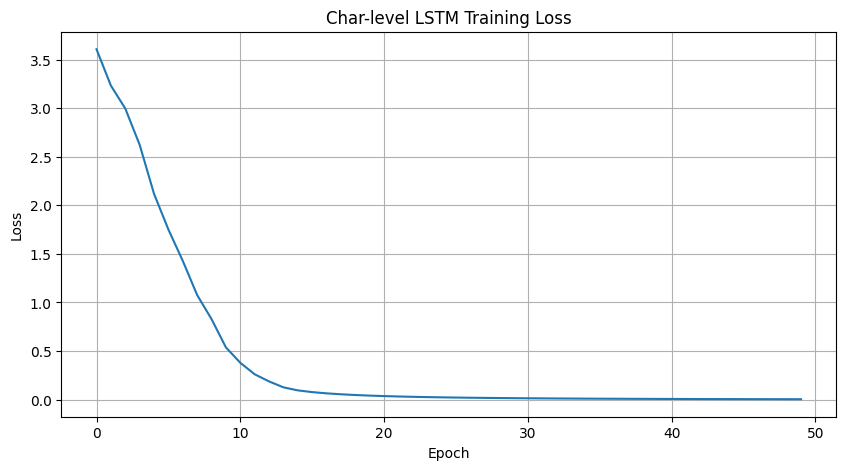

In [ ]:
def train_char_lstm(model, X_data, y_data, epochs=50, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    batch_size = 1 # For simplicity, we'll process one sequence at a time for char-level generation
                   # In real applications, you'd use a larger batch size and DataLoader

    # Ensure data is on the correct device
    X_data = X_data.to(device)
    y_data = y_data.to(device)

    loss_history = []

    print("Starting training...")
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        # Reset hidden state for each epoch (or each batch if batching is used)
        hidden = model.init_hidden(batch_size=1) # Initial hidden state for the first sequence

        for i in range(len(X_data)):
            input_seq = X_data[i].unsqueeze(0)  # (1, seq_length)
            target_char = y_data[i].unsqueeze(0) # (1)

            optimizer.zero_grad()

            # Detach hidden states from history to prevent backpropagating through the entire dataset
            hidden = (hidden[0].detach(), hidden[1].detach())

            output, hidden = model(input_seq, hidden)

            # The output of FC layer is (batch_size, seq_length, vocab_size)
            # For CrossEntropyLoss, we need (N, C) and (N) where N is the number of samples and C is the number of classes
            # Here, N = batch_size * seq_length, C = vocab_size
            # Since we are predicting the *next* character, we take the last output of the sequence
            loss = criterion(output[:, -1, :], target_char)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(X_data)
        loss_history.append(avg_loss)

        if epoch % 10 == 0 or epoch == epochs:
            print(f'Epoch {epoch:3d}/{epochs}, Loss: {avg_loss:.4f}')

    print("Training finished.")
    return loss_history

# Train the model
loss_history_char_lstm = train_char_lstm(model_char_lstm, X_data, y_data, epochs=50)

# Plot the training loss
plt.figure(figsize=(10, 5))
plt.plot(loss_history_char_lstm)
plt.title('Char-level LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()